In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('EV_Battery_Fault_Diagnosis.csv')

In [3]:
df

,Time (ms),Voltage (V),Current (A),Temperature (°C),Motor Speed (RPM),Hall Code,Estimated SOC (%),Ground Truth SOC (%),Residual (%),Fault Label
0,0,3.65,3.74,21.5,1350,111,88.7,87.7,1.0,Normal
1,100,3.59,2.33,35.3,1263,10,90.0,90.4,0.4,Normal
2,200,3.66,1.23,31.0,1267,10,97.9,98.6,0.7,Normal
3,300,3.75,2.50,38.2,1320,0,92.9,90.6,2.3,Warning
4,400,3.58,4.78,33.1,1290,1,92.9,92.2,0.7,Normal
...,...,...,...,...,...,...,...,...,...,...
2362,236200,3.45,3.59,21.5,1323,110,90.2,87.8,2.4,Warning
2363,236300,3.71,3.04,31.0,1324,100,87.8,84.6,3.2,Fault
2364,236400,3.54,2.78,26.0,1137,10,97.8,94.9,2.9,Warning
2365,236500,3.75,4.87,34.6,1143,1,95.5,92.9,2.6,Warning


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2367 entries, 0 to 2366
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time (ms)             2367 non-null   int64  
 1   Voltage (V)           2367 non-null   float64
 2   Current (A)           2367 non-null   float64
 3   Temperature (°C)      2367 non-null   float64
 4   Motor Speed (RPM)     2367 non-null   int64  
 5   Hall Code             2367 non-null   int64  
 6   Estimated SOC (%)     2367 non-null   float64
 7   Ground Truth SOC (%)  2367 non-null   float64
 8   Residual (%)          2367 non-null   float64
 9   Fault Label           2367 non-null   str    
dtypes: float64(6), int64(3), str(1)
memory usage: 185.1 KB


Hence there are no missing values in the dataset

In [5]:
df.describe()

,Time (ms),Voltage (V),Current (A),Temperature (°C),Motor Speed (RPM),Hall Code,Estimated SOC (%),Ground Truth SOC (%),Residual (%)
count,2367.000000,2367.000000,2367.000000,2367.000000,2367.000000,2367.000000,2367.000000,2367.000000,2367.000000
mean,118300.000000,3.603616,2.972260,29.793536,1246.498099,56.126320,92.574989,92.070046,1.271652
std,68343.836591,0.098817,1.146963,5.089657,88.100001,50.329444,4.331243,4.631731,0.950203
min,0.000000,3.280000,1.000000,12.100000,1100.000000,0.000000,85.000000,81.400000,0.000000
25%,59150.000000,3.540000,1.985000,26.400000,1169.000000,10.000000,88.800000,88.300000,0.500000
50%,118300.000000,3.600000,2.940000,29.800000,1243.000000,100.000000,92.700000,92.100000,1.100000
75%,177450.000000,3.670000,3.950000,33.200000,1325.500000,110.000000,96.300000,95.850000,1.800000
max,236600.000000,3.990000,5.000000,46.200000,1399.000000,111.000000,100.000000,103.000000,5.600000


In [6]:
df.columns

Index(['Time (ms)', 'Voltage (V)', 'Current (A)', 'Temperature (°C)',
       'Motor Speed (RPM)', 'Hall Code', 'Estimated SOC (%)',
       'Ground Truth SOC (%)', 'Residual (%)', 'Fault Label'],
      dtype='str')

Our target variable is Fault Label wherein on the other factors we need to predict if there's a fault in EV Battery or not


Here Fault=1 : Failure, Fault=0 : No failure

<h2>Checking for Missing Values</h2>

In [7]:
df.isnull().sum()

Time (ms)               0
Voltage (V)             0
Current (A)             0
Temperature (°C)        0
Motor Speed (RPM)       0
Hall Code               0
Estimated SOC (%)       0
Ground Truth SOC (%)    0
Residual (%)            0
Fault Label             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

It shows that there are no duplicate values in the dataset

<h5>Lets check for Class Distribution of Faults</h5>

In [9]:
df['Fault Label'].value_counts()

Fault Label
Normal     1150
Warning    1081
Fault       136
Name: count, dtype: int64

Percentage of values that belong to each class:

In [10]:
print(df['Fault Label'].value_counts(normalize=True)*100)

Fault Label
Normal     48.584706
Warning    45.669624
Fault       5.745670
Name: proportion, dtype: float64


<h2>Fault Distribution across all classes</h2>

Visualizing the Fault Distribution across all the classes:

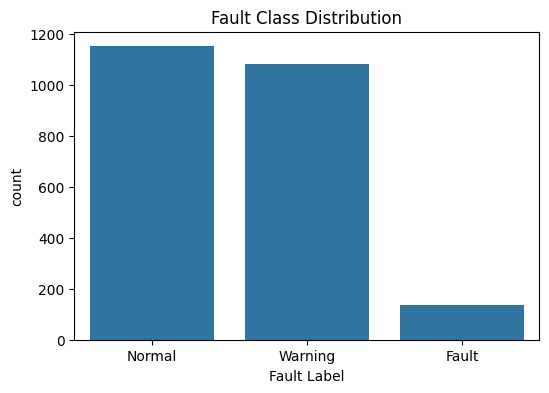

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="Fault Label", data=df)
plt.title("Fault Class Distribution")
plt.show()

<h2>Feature Distribution Plots</h2>

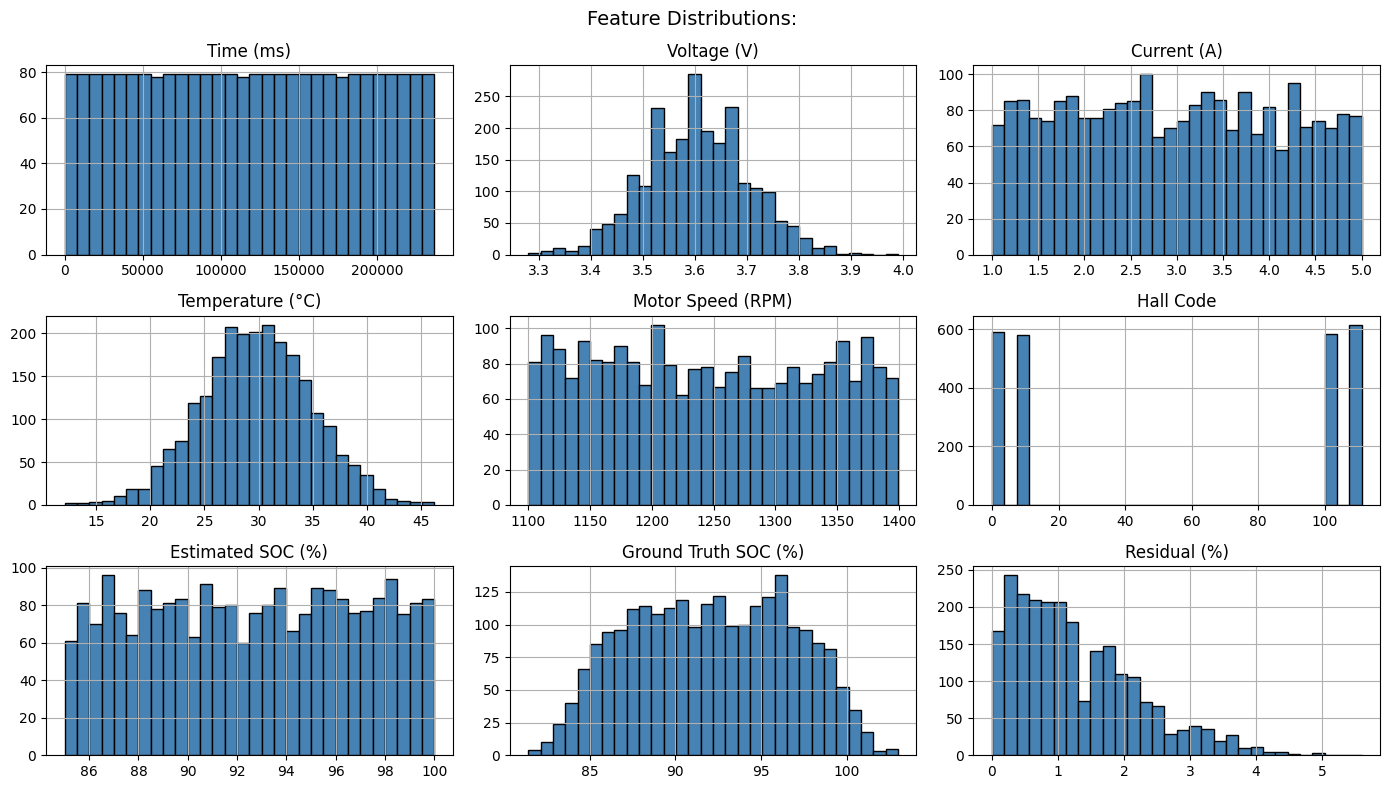

In [12]:
features = ["Time (ms)",
"Voltage (V)",
"Current (A)",
"Temperature (°C)",
"Motor Speed (RPM)",
"Hall Code",
"Estimated SOC (%)",
"Ground Truth SOC (%)",
"Residual (%)",
"Fault Label"]

df[features].hist(figsize=(14,8), bins=30, color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions: ", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
features

['Time (ms)',
 'Voltage (V)',
 'Current (A)',
 'Temperature (°C)',
 'Motor Speed (RPM)',
 'Hall Code',
 'Estimated SOC (%)',
 'Ground Truth SOC (%)',
 'Residual (%)',
 'Fault Label']

So, Time (ms) feature has a perfectly flat / uniform distribution, its just a timestamp hence it doen't carries any information so we can remove it

And Hall Code

Only 3 distinct values (0, 10, 100) — looks like a categorical code, not a continuous sensor reading

Doesn't contain any meaningful sensor information so drop it as well

In [14]:
df = df.drop(columns=['Time (ms)', 'Hall Code'])

In [15]:
df.columns

Index(['Voltage (V)', 'Current (A)', 'Temperature (°C)', 'Motor Speed (RPM)',
       'Estimated SOC (%)', 'Ground Truth SOC (%)', 'Residual (%)',
       'Fault Label'],
      dtype='str')

Also we have both features of SOC:

SOC Ground Truth(%) and Estimated SOC Error(%)

So we can find the SOC_Error as SOC Ground Truth - Estimated SOC

In [16]:
df['SOC_Error'] = df['Ground Truth SOC (%)'] - df['Estimated SOC (%)']

In [17]:
print("Columns after dropping: ", df.columns.tolist())

Columns after dropping:  ['Voltage (V)', 'Current (A)', 'Temperature (°C)', 'Motor Speed (RPM)', 'Estimated SOC (%)', 'Ground Truth SOC (%)', 'Residual (%)', 'Fault Label', 'SOC_Error']


In [18]:
df.shape

(2367, 9)

Now separate the target variable from the dataset

In [19]:
y = df["Fault Label"]

In [20]:
y

0        Normal
1        Normal
2        Normal
3       Warning
4        Normal
         ...   
2362    Warning
2363      Fault
2364    Warning
2365    Warning
2366     Normal
Name: Fault Label, Length: 2367, dtype: str

In [21]:
X = df[['Voltage (V)',
        'Current (A)',
        'Temperature (°C)',
        'Motor Speed (RPM)',
        'Estimated SOC (%)',
        'Ground Truth SOC (%)',
        'Residual (%)',
        'SOC_Error']]

In [22]:
print("Features shape: ", X.shape)

Features shape:  (2367, 8)


In [23]:
print("Target Shape: ", y.shape)

Target Shape:  (2367,)


In [24]:
print("Target Distribution:", y.value_counts())

Target Distribution: Fault Label
Normal     1150
Warning    1081
Fault       136
Name: count, dtype: int64


The data is imbalanced as the model may mostly predict Warning and Normal as their frequency is high and start ignoring the fault class

So, inorder to balance this we use SMOTE - Synthetic Minority Oversampling TEchnique

SMOTE helps to create fake but realistic new samples of the minority class (here, Fault) to balance your dataset

In [25]:
from sklearn.preprocessing import LabelEncoder
# label Encoder converts text labels to numbers


In [26]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

#Mapping all the text values to numeric data like:
#Normal-0
#Warning-1
#Fault-2
print("Label Mapping: ", dict(zip(le.classes_, le.transform(le.classes_))))


Label Mapping:  {'Fault': np.int64(0), 'Normal': np.int64(1), 'Warning': np.int64(2)}


In [27]:
print("Encoded Dsitribution: ")
print(pd.Series(y_encoded).value_counts())

Encoded Dsitribution: 
1    1150
2    1081
0     136
Name: count, dtype: int64


Apply SMOTE

In [28]:
!pip install imblearn
from imblearn.over_sampling import SMOTE
from collections import Counter


   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]



In [29]:
print("Before SMOTE: ", Counter(y_encoded))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_encoded)

print("After SMOTE: ", Counter(y_resampled))

Before SMOTE:  Counter({np.int64(1): 1150, np.int64(2): 1081, np.int64(0): 136})
After SMOTE:  Counter({np.int64(1): 1150, np.int64(2): 1150, np.int64(0): 1150})


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
print("Train size: ", X_train_scaled.shape)
print("Test size: ", X_test_scaled.shape)


Train size:  (2760, 8)
Test size:  (690, 8)


<h2>Random Forest</h2>

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [34]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
rf_pred = rf.predict(X_test_scaled)



<h2>Classification Reports for both Models: </h2>

In [36]:
print("------------ RANDOM FOREST RESULTS -----------")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

------------ RANDOM FOREST RESULTS -----------
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

       Fault       1.00      1.00      1.00       221
      Normal       1.00      1.00      1.00       253
     Warning       1.00      1.00      1.00       216

    accuracy                           1.00       690
   macro avg       1.00      1.00      1.00       690
weighted avg       1.00      1.00      1.00       690



In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_scaled, y_train)

xgb_pred = xgb.predict(X_test_scaled)


In [39]:
print("XGBoost Results: ")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

XGBoost Results: 
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

       Fault       1.00      1.00      1.00       221
      Normal       1.00      1.00      1.00       253
     Warning       1.00      1.00      1.00       216

    accuracy                           1.00       690
   macro avg       1.00      1.00      1.00       690
weighted avg       1.00      1.00      1.00       690



<h2>Confusion Matrix Plot:</h2>

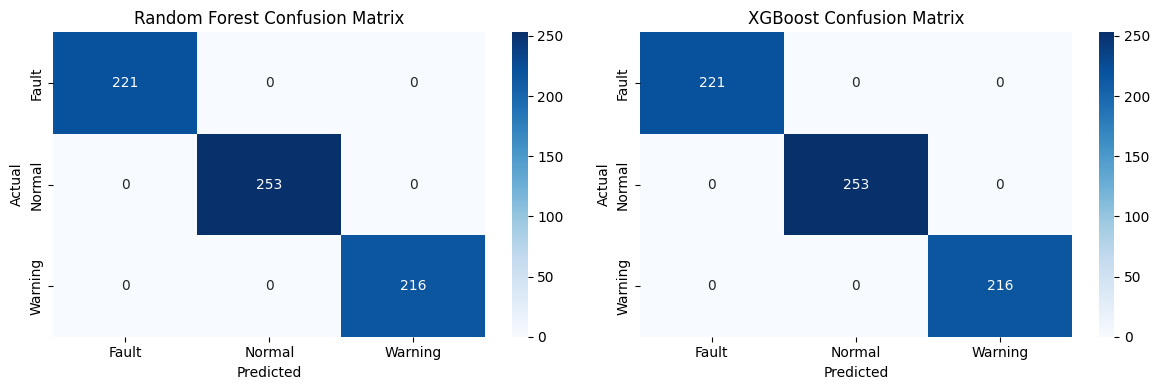

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in zip(axes, [rf_pred, xgb_pred],
                                  ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

<h2>Feature Importance</h2>

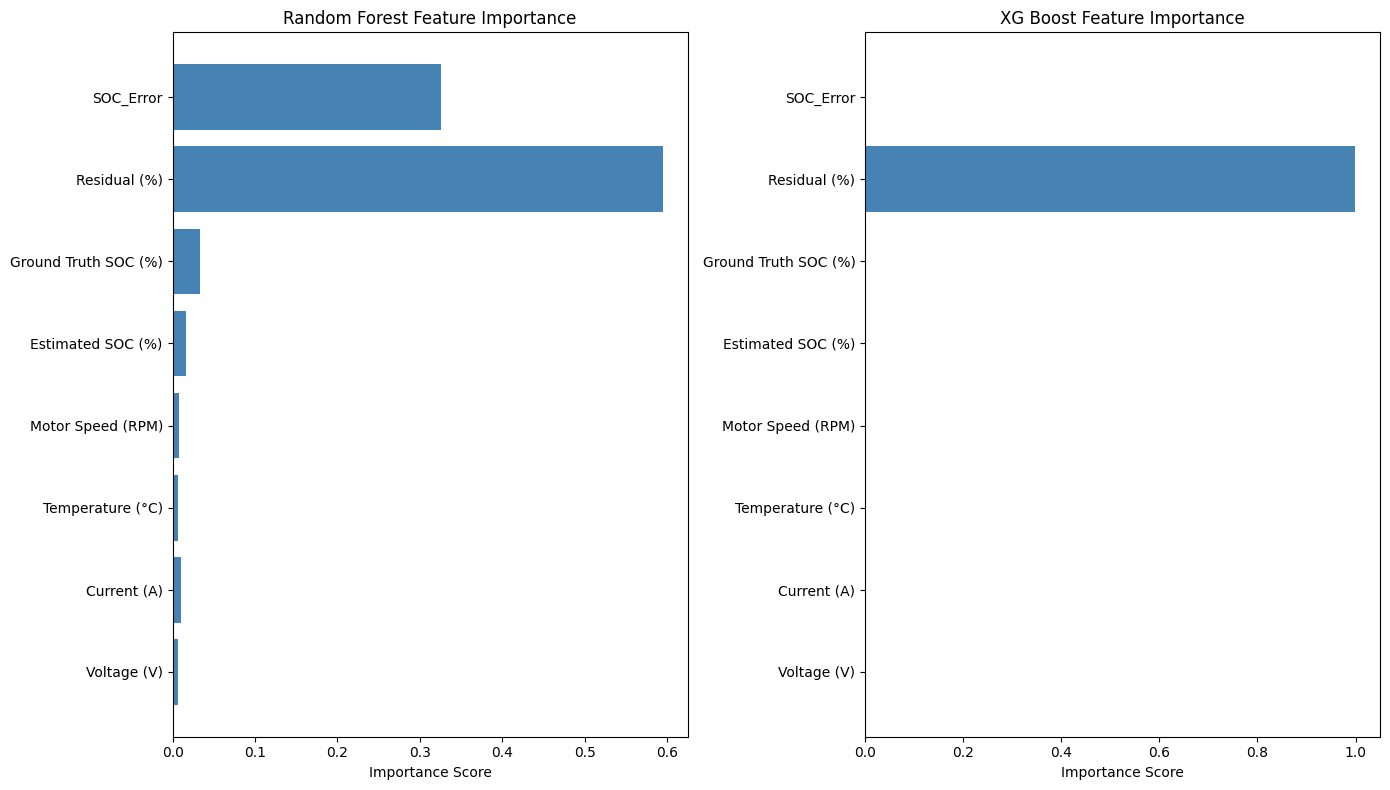

In [41]:
feat_names = X.columns.tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, model, title in zip(axes, [rf, xgb], ['Random Forest', 'XG Boost']):
    importances =  model.feature_importances_
    ax.barh(feat_names, importances, color='steelblue')
    ax.set_title(f'{title} Feature Importance')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

Residual (%) is by far the most powerful fault indicator — both models agree. This makes perfect sense because Residual directly measures the error between estimated and actual battery behavior.

XGBoost is relying almost entirely on Residual (%) — this is a red flag actually. It means XGBoost found one feature so perfectly separating the classes that it ignored everything else. This could indicate the dataset is slightly too easy or the Residual column is directly derived from the fault labels.

<table>
    <head>
        <td><b>Metric </b></td>
        <td><b>Random Forest</b></td>
        <td><b>XG Boost</b></td>
    </head>
    <tr>
        <td>Accuracy</td>
        <td>100 %</td>
        <td>100 %</td>
    </tr>
    <tr>
        <td>Fault Recall</td>
        <td>1.00</td>
        <td>1.00</td>
    </tr>
    <tr>
        <td>Best Feature</td>
        <td>Residual (%)</td>
        <td>Residual (%)</td>
    </tr>
</table>

In [42]:
import joblib

In [43]:
joblib.dump(rf, 'random_forest_battery_model.pkl')
print("Model Saved !")

Model Saved !


In [44]:
joblib.dump(xgb, 'xgboost_battery_model.pkl')
print('Model Saved !')

Model Saved !


Save the scaler files as well as they need to be used by the model before predicting for future predictions as well

In [45]:
joblib.dump(scaler, 'scaler_battery_model.pkl')
print("Scaler saved !")

Scaler saved !


In [46]:
joblib.dump(le, 'label_encoder_model.pkl')
print("Label Encoder saved !")

Label Encoder saved !


In [47]:
from google.colab import files

ModuleNotFoundError: No module named 'google'

In [51]:
files.download('random_forest_battery_model.pkl')
files.download('xgboost_battery_model.pkl')
files.download('scaler_battery_model.pkl')
files.download('label_encoder_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>